# Introduction
The goal of this notebook is to fit the lightcurves of AGNs. For the first part, we will only consider fitting normalized lightcurves, i.e. not taking into account the mean yet.

## Model
Let $ \delta $ represent the data and $ \alpha , A $ be the parameters of the power spectrum. we use
$$ p(\alpha, A, \sigma|\delta) \propto (\delta|x, \sigma)p(x|\alpha, A)p(\alpha)p(A) $$
Here, 
$$  x \sim \mathcal{N}(y, \sigma)  $$
$$  y \sim Power Law Spectrum Prior(\alpha, A)  $$
$$  A \sim \mathcal{HN}(10)  $$
$$  \alpha \sim \mathcal{N}(1.7, 5)  $$
$$  \sigma \sim \mathcal{HN}(10)  $$

# Imports

In [3]:
import sqlite3
from contextlib import closing
import pandas as pd
import time
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.utils.constants import M_sun
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # pick whichever GPU has more free memory
# os.environ["CUDA_VISIBLE_DEVICES"] = "" 
# os.environ["JAX_PLATFORMS"] = "cpu"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.instrument import Instrument
from cosmographi.instrument.rubin import RubinObservatory
import numpy as np
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun, c_nm
from cosmographi.utils.flux import convert_to_jy, observer_to_rest_time
# jax.config.update("jax_enable_x64", True)
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.cosmology import Cosmology
import arviz as az
import blackjax as bx
import jax.scipy.stats as stats
from functools import partial
import cosmographi as cp
import matplotlib.pyplot as plt

In [4]:
import jax
print(jax.devices())

[CudaDevice(id=1)]


# Getting the data
This example is for one sample only. 

In [ ]:
np.random.seed(0)
key, key2 = jax.random.split(jax.random.PRNGKey(0))

# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 50000;
        """
    survey_df = pd.read_sql_query(query, conn)
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values


# Create source
#####################################################################
perturbations = generate_perturbations_vector (alpha=0.7, n_samples = 4000)
print(perturbations)
C = cp.Cosmology()
source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, A_V_c00mw=0.1, R_V_c00mw=3.1, blackhole_mass=1e10*M_sun, accretion_rate=M_sun, rin_to_rng=6, inclination_angle=0, perturbations_ar=perturbations, start_time=60900, end_time=65000)


#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band, return_dict=True)
nfilter = len(I.throughput.bands)
print(I.get_values().shape)

# Generate mock SN
#####################################################################
Nsn = 1
t_range = (np.min(survey_t), np.max(survey_t))
source_t = np.random.uniform(*t_range, Nsn)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing


source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)

print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin = np.full(Nsn, np.min(survey_t)),
    source_tmax= np.full(Nsn, np.max(survey_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
# TODO: MAKE PRIORS
# P = cp.source.prior.SALT2_SK16Prior()
# x1, c = P.prior_sample(source_t.shape[0])
# S.x1 = x1
# S.c = c
sel_src = np.sort(list(source_matches.keys()))
print(sel_src)

# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)
keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))


# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time.time()
LCs = []
nobs = len(keys)

#TODO: had to lower, what is eating up my memory??

batch_size = 50

print("batch_size =", batch_size)
i = 0
print("keys", keys[i:i+batch_size].shape)
print("bands", bands[i:i+batch_size].shape)
print("exp_times", exp_times[i:i+batch_size].shape)
print("sky_brightnesses", sky_brightnesses[i:i+batch_size].shape)
print("PSF_Aeffs", PSF_Aeffs[i:i+batch_size].shape)
print("obs_t", obs_t[i:i+batch_size].shape)
print("source_params", source_params[i:i+batch_size].shape)
print("survey_params", survey_params[i:i+batch_size].shape)

for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],  
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)

seli = sel_src[0]
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
times = obs_t[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]
lc_err = LCs[0][spot : spot + len(source_matches[seli])]

print(lc_obs)

[-2.2487586  -2.54369013 -2.09328988 ... -0.78817621 -0.93063772
 -0.32865155]
(1,)


[0.83781118]
Matching sources to survey...
Matched 1 sources to survey observations.
Matched 1 sources worth examining.
[0]
batch_size = 50
keys (8, 2)
bands (8,)
exp_times (8,)
sky_brightnesses (8,)
PSF_Aeffs (8,)
obs_t (8,)
source_params (8, 2)
survey_params (8, 1)
[[0.00180429]
 [0.00115868]
 [0.00110436]
 [0.00179473]
 [0.0021101 ]
 [0.00203946]
 [0.00114007]
 [0.00178902]]


# Defining Model

In [4]:
def halfnormal_logpdf(x, scale):
    return jnp.where(x > 0,jnp.log(2.0) + stats.norm.logpdf(x, loc=0.0, scale=scale),- jnp.inf) 

In [ ]:
def log_prior_alpha(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on alpha evaluated at <evaluate_at>.
    alpha ~ Normal(0, 5)
    """
    return stats.norm.logpdf(evaluate_at, loc=1.7, scale=5.0)

def log_prior_A(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on A evaluated at <evaluate_at>.
    A ~ HalfNormal(10)
    """
    return halfnormal_logpdf(evaluate_at, 10)

def log_prior_sigma(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on A evaluated at <evaluate_at>.
    A ~ HalfNormal(10)
    """
    return halfnormal_logpdf(evaluate_at, 10)

@jax.jit
def power_spectrum_log_prior(alpha, A, x, var_floor: float = 1e-8) -> jnp.ndarray:
    """
    Evaluates the log-prior probability density of a 1D real-valued array x,
    assuming a power-law power spectrum P(k) = amplitude * k^alpha.

    Args:
        x: 1D array of real-valued data.
        alpha: The power law slope of the spectrum.
        amplitude: Scaling factor for the power spectrum. 
        var_floor: A floor applied to the total variance to prevent division
                   by zero and ensure numerical stability in gradients. consider removing?

    Returns:
        log_prob: The scalar log-probability density.
    
    Mean handling: let mean float / model sepparately gaussian

    """
    N = x.shape[0]

    # 1. Transform to frequency domain
    x_k = jnp.fft.rfft(x)
    freqs = jnp.fft.rfftfreq(N)

    # 2. Isolate non-zero frequencies
    # The DC component (k=0) is excluded to avoid singular values.
    # It is typically assumed the signal is mean-centered, or the mean
    # is modeled with a separate uniform/normal prior.
    k_nz = freqs[1:]
    x_k_nz = x_k[1:]

    # 3. Compute expected power spectrum variance
    # Applying the variance floor prevents the variance from dropping to zero
    # (e.g., at high frequencies if alpha < 0) which would cause log(0) NaNs.
    P_k = A / (k_nz ** alpha) + var_floor # changed to match generate_perturbations_vector

    # 4. Calculate log probability of the Fourier modes
    # The rfft coefficients for k > 0 are independent complex Gaussians.
    # The variance of these complex modes is proportional to P(k).
    power_x = jnp.abs(x_k_nz)**2

    # Log PDF of a complex Gaussian: -|z|^2 / Var - log(pi * Var)
    log_prob_modes = -(power_x / P_k) - jnp.log(jnp.pi * P_k)

    # Sum over all independent modes to get the total log-prior
    return jnp.sum(log_prob_modes) - jnp.mean(x)**2 # add gaussian centred around 0 for the mean
    # flux parameter will absorb changes in averag

def log_prior(params):
    alpha = params["alpha"]
    A = params["A"]
    x = params["x"]
    return log_prior_alpha(alpha) + log_prior_A(A) + power_spectrum_log_prior(alpha, A, x)

# go through supernova fitting example in caskade cdocumentation
# turn everythin ingot ck.Params
# likelihood will need to be rewritten in ck.
# dont sample over isgma
# create object once!!


def log_likelihood(params, y, times, redshift, instrument: Instrument, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray):
    start_time, end_time = times[0], times[-1]
    x = params["x"]
    bh_mass = params["bh_mass"]
    acc_rate = params["acc_rate"]
    inclination = params["inclination"]
    rin_to_rng = params["rin_to_rng"]
    A_V_c00mw = params["A_V_c00mw"]
    R_V_c00mw = params["R_V_c00mw"]
    luminosity_scaling = params["luminosity_scaling"]
    sigma = params["sigma"]
    C = cp.cosmology.Cosmology()
    source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
    S = source_obj(cosmology=C, A_V_c00mw=A_V_c00mw, R_V_c00mw=R_V_c00mw, blackhole_mass=bh_mass, accretion_rate=acc_rate, rin_to_rng=rin_to_rng, inclination_angle=inclination, perturbations_ar=x, start_time=start_time, end_time=end_time,  luminosity_density_scaling=luminosity_scaling)
    S.z = redshift
    S.t0 = start_time
    source_values = jnp.asarray(S.get_values())
    survey_values = instrument.get_values()
    band, exp_time, sky_brightness,PSF_Aeff = jnp.atleast_1d(band), jnp.atleast_1d(exp_time), jnp.atleast_1d(sky_brightness), jnp.atleast_1d(PSF_Aeff)
    obs = jax.vmap(instrument.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    result = obs(key, band, exp_time, sky_brightness, PSF_Aeff, S, times, source_values, survey_values)[0] # TODO: is it supposed to be this one? bc there is randomness in the rror too
    return - 0.5* jnp.sum(((y - result)/sigma)**2) # TODO: check out chi distribution (beams paper)
    # x is perturbation value, not model value
    # want model value to the mean of x
    # create agn, instrument, etc., -> Instrument.observe -> compare true flux values with observed flux values, divide by observed flux values
    # pass in X as AGNSource(pertubations_ar)

def log_posterior(params, y, times, redshift, instrument: Instrument, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray):
    return log_likelihood(params, y, times, redshift, instrument, key, band, exp_time, sky_brightness, PSF_Aeff) + log_prior(params)

# true perturbationsvs perturbations plot!
# observed fluxes vs model fluxes plot!
# distrbutions of parameters w/ true values

# Fitting 

In [3]:
# def bandwise_mean_norm(y, band):
#     sum_ar = jax.ops.segment_sum(y, band, num_segments=len(jnp.unique(band)))
#     count_ar = jax.ops.segment_sum(jnp.ones_like(y), band, num_segments=len(jnp.unique(band)))
#     averages = sum_ar / count_ar
#     return ((y / averages[band]) - 1, averages)

# def invert_bandwise_mean_norm(y_norm, band, averages):
#     return (y_norm + 1) * averages[band]

In [6]:
num_samples = 5000
key3 = keys[0]
key4 = keys[1]
# y, y_mean = bandwise_mean_norm(lc_obs, bands[spot : spot + len(source_matches[seli])])
initial_position = {"alpha": jnp.array(1.7), "A": jnp.array(5.0), "x": jnp.zeros(len(times)), "bh_mass": jnp.array(M_sun*1e8), "acc_rate": jnp.array(0.5*M_sun), "inclination": jnp.array(0.0), "rin_to_rng": jnp.array(6.0), "A_V_c00mw": jnp.array(0.2), "R_V_c00mw": jnp.array(3.0), "luminosity_scaling": jnp.array(1.0)}
target_log_posterior = partial(log_posterior, y=lc_obs, times=times, redshift=source_z, instrument=I, key=key3, band=bands, exp_time=exp_times, sky_brightness=sky_brightnesses, PSF_Aeff=PSF_Aeffs)
warmup = bx.window_adaptation(bx.hmc, target_log_posterior, num_integration_steps=1000)
adaptation_results, adaptation_info = warmup.run(key, initial_position)
kernel = bx.hmc(target_log_posterior, **adaptation_results.parameters).step


def one_step(state, key):
    state, info = kernel(key, state)
    return state, state

@jax.jit
def run_chain(initial_state, keys):
    return jax.lax.scan(one_step, initial_state, keys)

final_state, history = run_chain(adaptation_results.state, keys[2:])
jax.block_until_ready(history.position["alpha"])
jax.block_until_ready(history.position["A"])
jax.block_until_ready(history.position["x"])
jax.block_until_ready(history.position["bh_mass"])
jax.block_until_ready(history.position["acc_rate"])
jax.block_until_ready(history.position["inclination"])
jax.block_until_ready(history.position["rin_to_rng"])
jax.block_until_ready(history.position["A_V_c00mw"])
jax.block_until_ready(history.position["R_V_c00mw"])
jax.block_until_ready(history.position["luminosity_scaling"])
alpha_samples = jnp.asarray(history.position["alpha"])
A_samples = jnp.asarray(history.position["A"])
x_samples = jnp.asarray(history.position["x"])
bh_mass_samples = jnp.asarray(history.position["bh_mass"])
acc_rate_samples = jnp.asarray(history.position["acc_rate"])
inclination_samples = jnp.asarray(history.position["inclination"])
rin_to_rng_samples = jnp.asarray(history.position["rin_to_rng"])
A_V_c00mw_samples = jnp.asarray(history.position["A_V_c00mw"])
R_V_c00mw_samples = jnp.asarray(history.position["R_V_c00mw"])
luminosity_scaling_samples = jnp.asarray(history.position["luminosity_scaling"])

NameError: name 'keys' is not defined

In [ ]:
idata = az.from_dict(posterior={"alpha": np.asarray(alpha_samples)[None, :], "A": np.asarray(A_samples)[None, :], 
                                "x": np.asarray(x_samples)[None, :], "bh_mass": np.asarray(bh_mass_samples)[None, :],
                                "acc_rate": np.asarray(acc_rate_samples)[None, :], "inclination": np.asarray(inclination_samples)[None, :],
                                "rin_to_rng": np.asarray(rin_to_rng_samples)[None, :], "A_V_c00mw": np.asarray(A_V_c00mw_samples)[None, :],
                                "R_V_c00mw": np.asarray(R_V_c00mw_samples)[None, :], "luminosity_scaling": np.asarray(luminosity_scaling_samples)[None, :]})


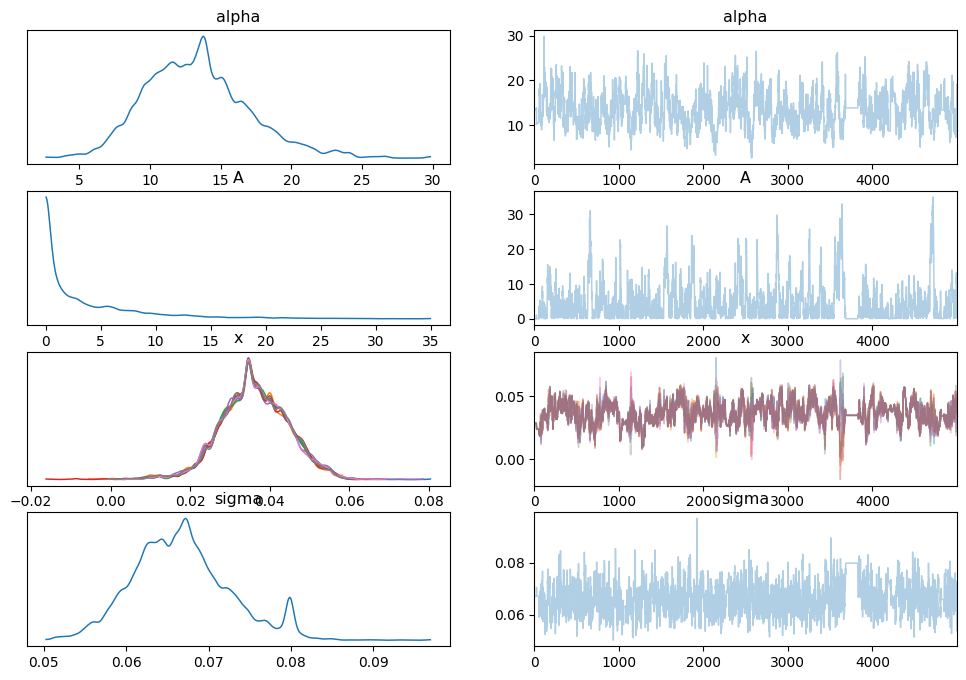

In [ ]:
true_values = {"alpha": 1.7, "A": 5.0, "x": perturbations, "bh_mass": 1e10*M_sun, "acc_rate": M_sun, "inclination": 0, "rin_to_rng": 6, "A_V_c00mw": 0.1, "R_V_c00mw": 3.1, "luminosity_scaling": 1.0}

axes = az.plot_trace(idata)
for i, var in enumerate(idata.posterior.data_vars):
    if var in true_values:
        axes[i, 0].axhline(true_values[var], color="red", ls="--", lw=2)
        axes[i, 1].axvline(true_values[var], color="red", ls="--", lw=2)
plt.show()
# add true value line

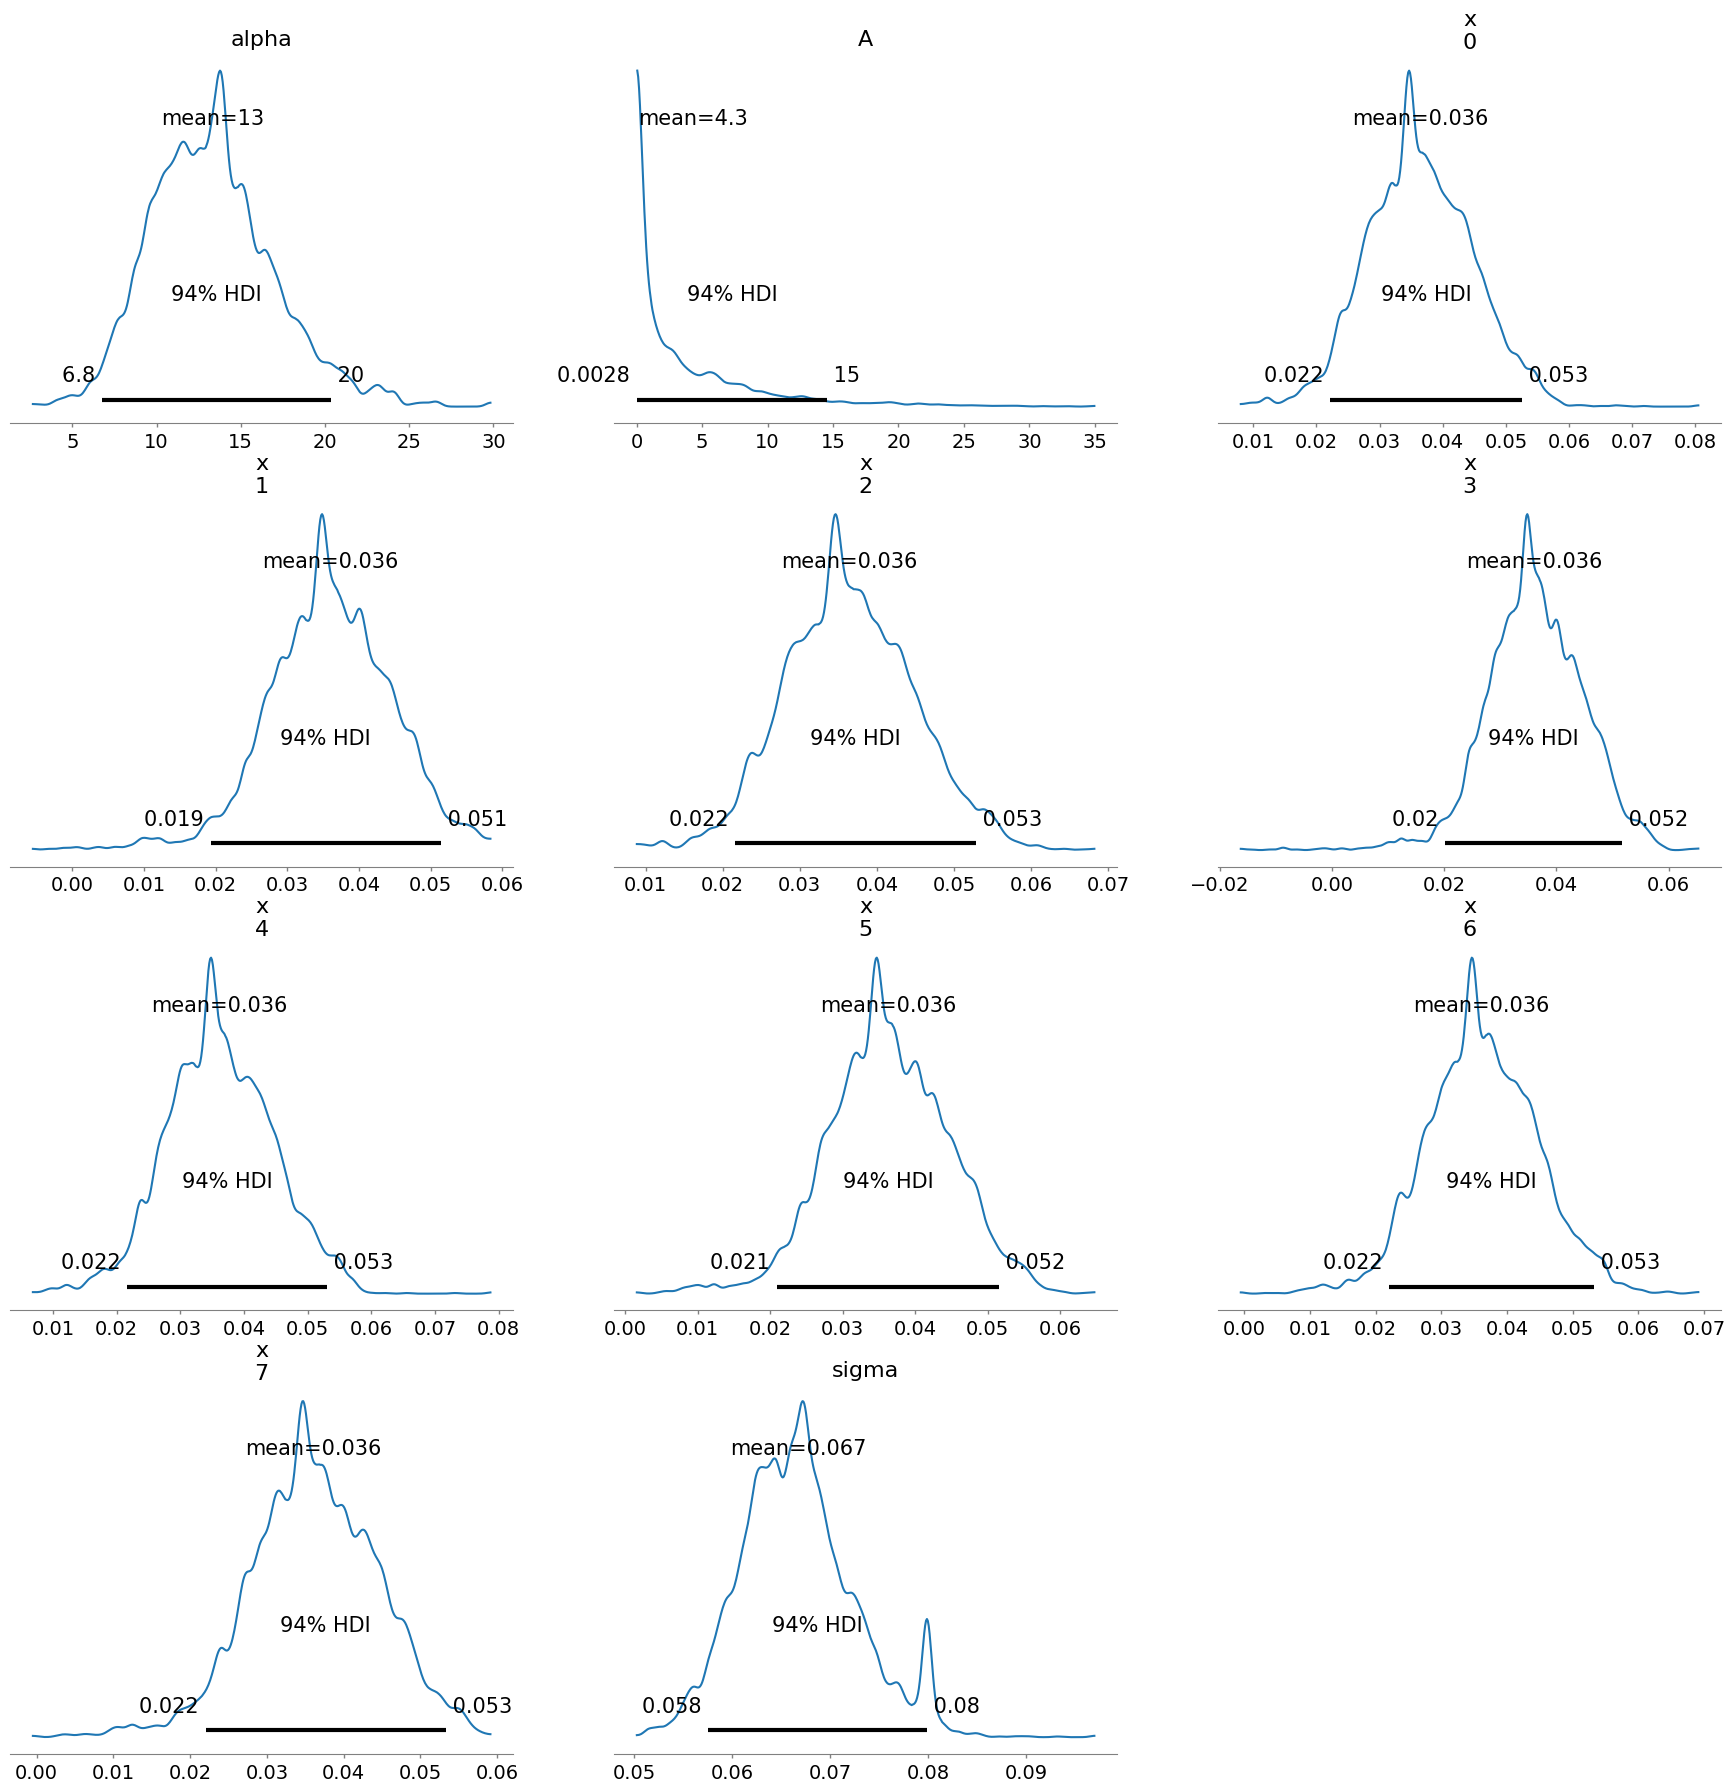

In [ ]:
axes = az.plot_posterior(idata)
for ax, var in zip(axes, idata.posterior.data_vars):
    if var in true_values:
        ax.axvline(true_values[var], color="red", linestyle="--", linewidth=2)
plt.show()

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:233: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


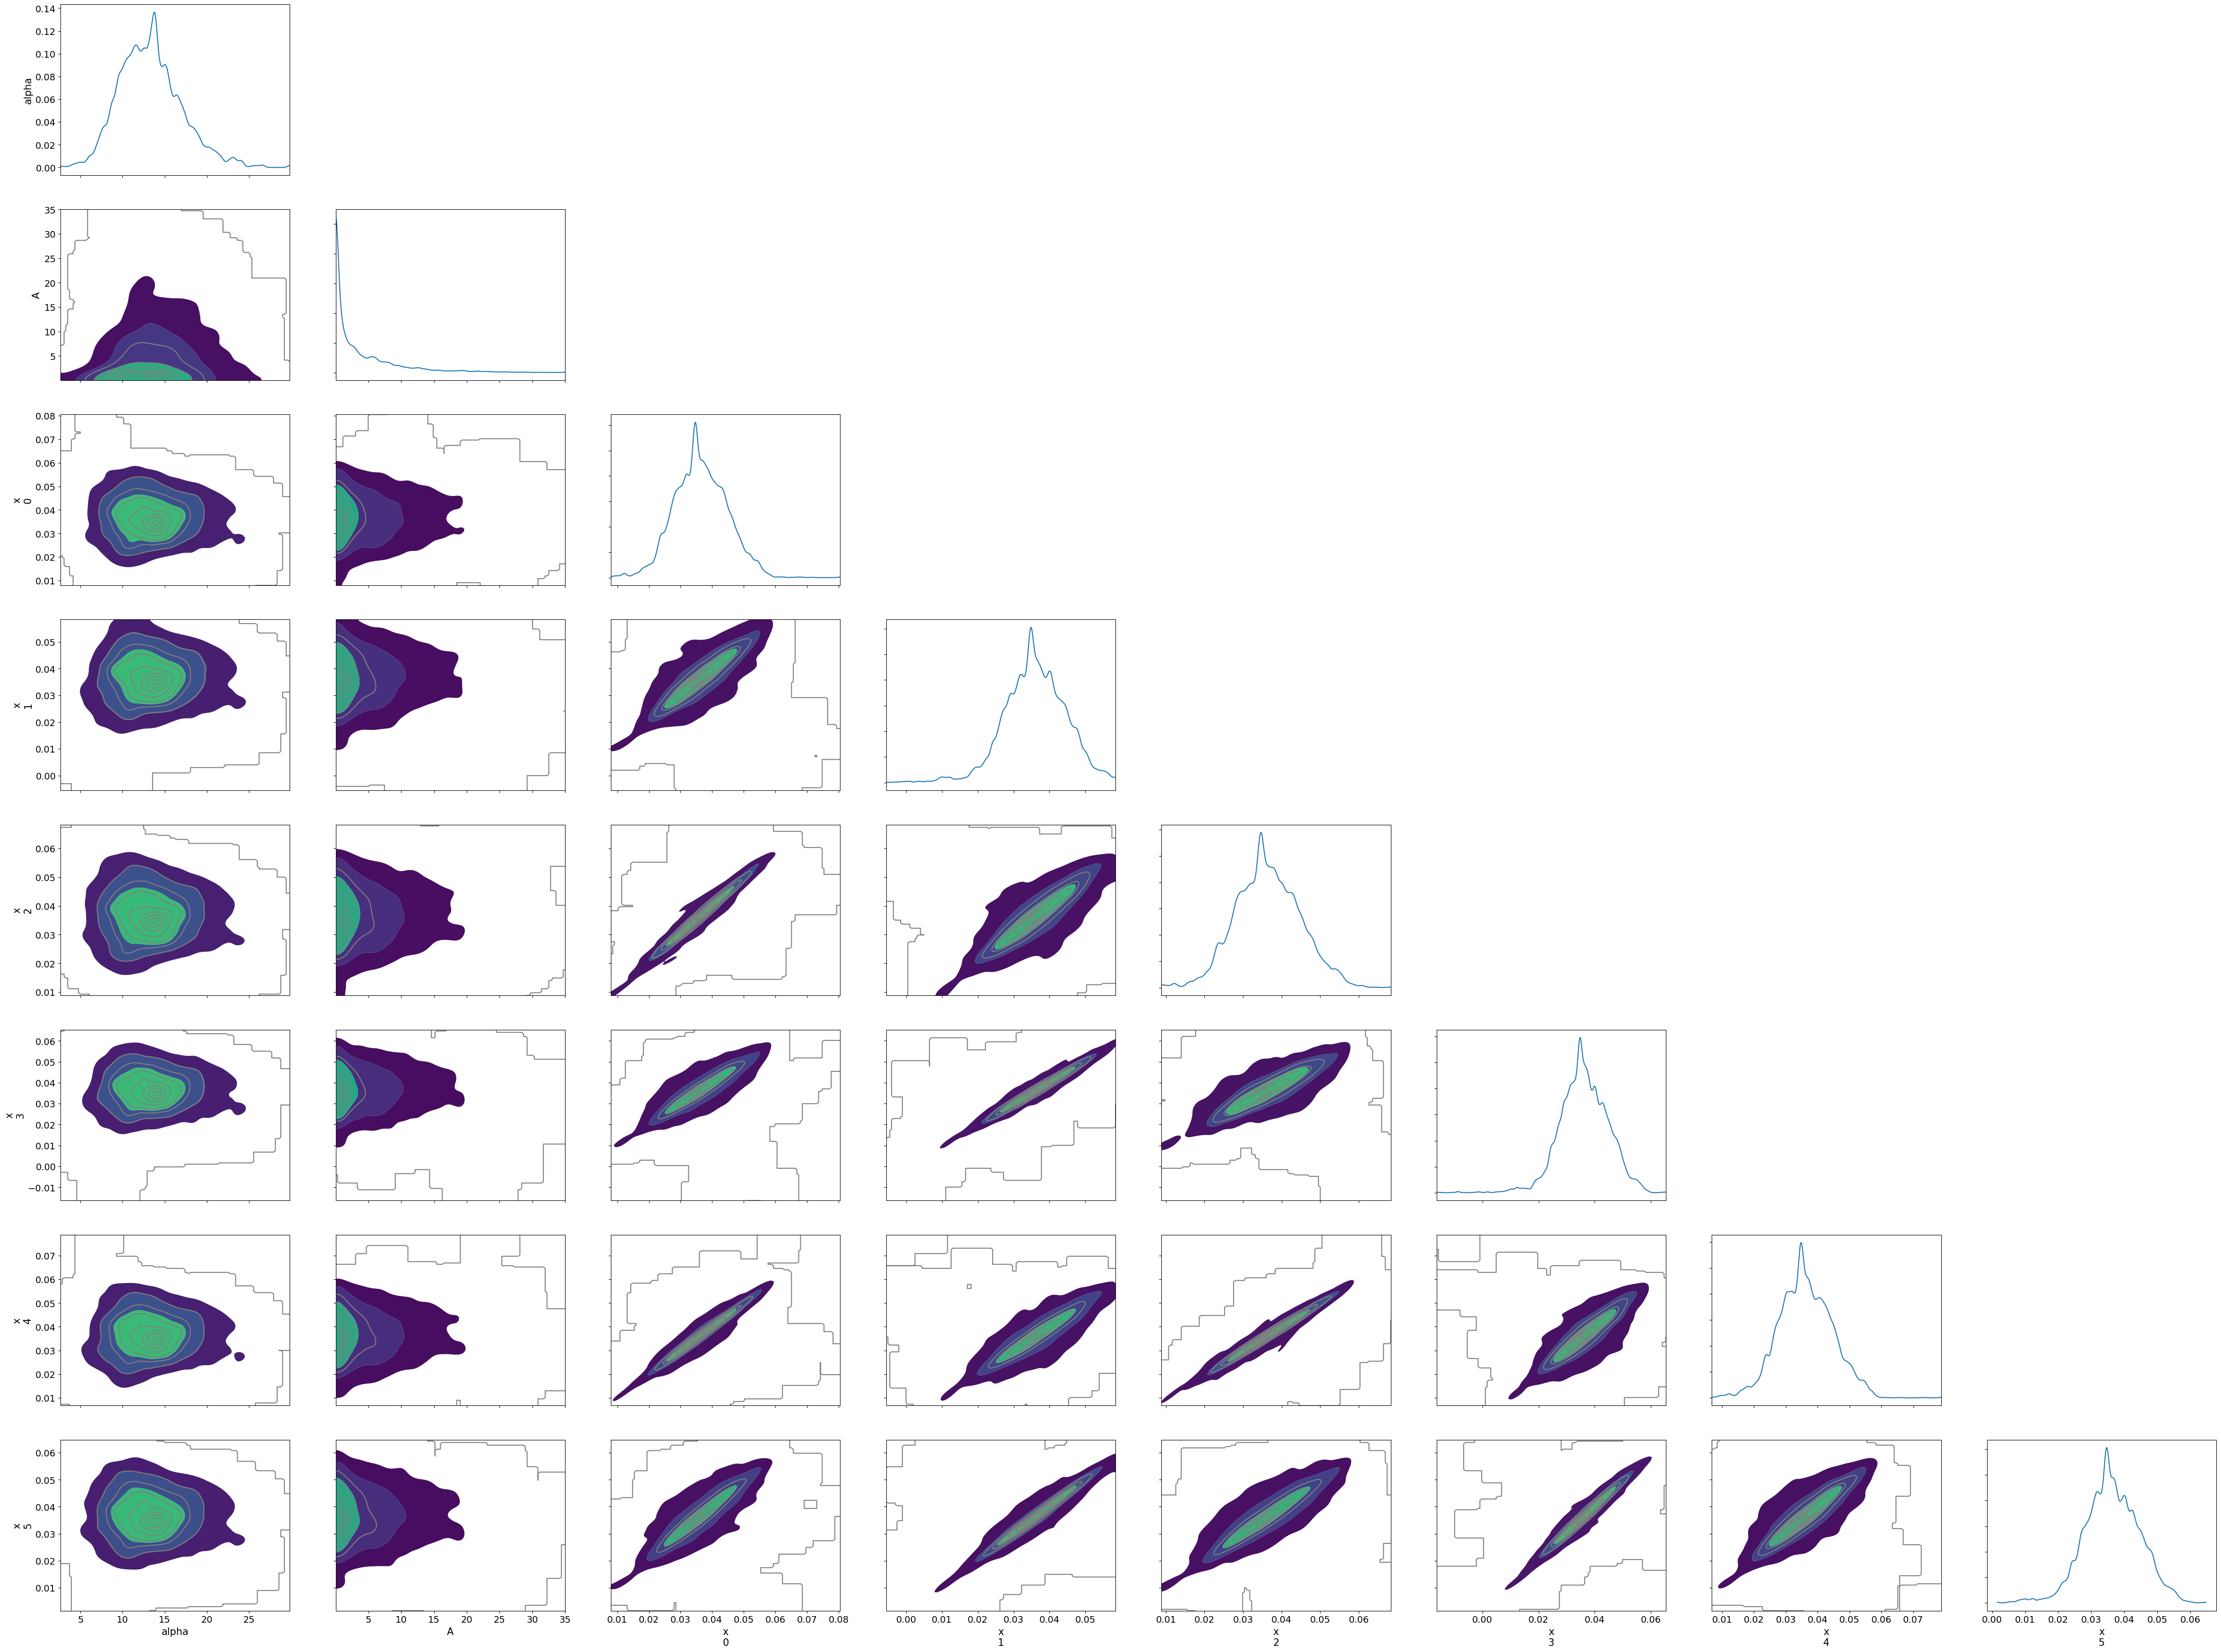

In [ ]:
az.plot_pair(idata, kind="kde", marginals=True)
plt.show()

In [ ]:
# def fitted_spectrum_simple(alpha_samples, A_samples, sigma_samples, n_samples, band, averages, key):
#    averages = averages.squeeze()
#    perturbations = jax.vmap(generate_perturbation, in_axes=(0,0,None, None))(alpha_samples, A_samples, n_samples, key)
#    mean = invert_bandwise_mean_norm(perturbations, band, averages)
#    noise = sigma_samples[:, None] * jax.random.normal(key, shape=mean.shape)
#    return noise + mean 

In [ ]:
def generate_sources(x_samples, bh_mass_samples, acc_rate_samples, inclination_samples, rin_to_rng_samples, A_V_c00mw_samples, R_V_c00mw_samples, luminosity_scaling_samples, times):
    source = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
    C = cp.cosmology.Cosmology()
    start_time, end_time = times[0], times[-1]
    vinit = jax.vmap(source.__init__, in_axes=(None, None, 0, 0, 0, 0, 0, None, None, 0, 0, 0))
    print("creating sources")
    source_array = vinit(C, "agn", bh_mass_samples, acc_rate_samples, inclination_samples, rin_to_rng_samples, x_samples, start_time, end_time, luminosity_scaling_samples, A_V_c00mw_samples, R_V_c00mw_samples)
    return source_array

In [ ]:
def generate_fited_spectrum(x_samples, bh_mass_samples, acc_rate_samples, inclination_samples, rin_to_rng_samples, A_V_c00mw_samples, R_V_c00mw_samples, luminosity_scaling_samples, instrument, times, key, band, exp_time, sky_brightness, PSF_Aeff):
    source_array = generate_sources(x_samples, bh_mass_samples, acc_rate_samples, inclination_samples, rin_to_rng_samples, A_V_c00mw_samples, R_V_c00mw_samples, luminosity_scaling_samples, times)
    vobs = jax.vmap(instrument.observe, in_axes=(None, 0, 0, 0, 0, 0, 0, 0, None))
    print("generating spectra")
    spectra = vobs(key, band, exp_time, sky_brightness, PSF_Aeff, source_array, times, source_array.get_values(), instrument.get_values())
    return spectra

In [ ]:
alpha_samples = idata.posterior["alpha"].values.flatten()
A_samples = idata.posterior["A"].values.flatten()
x_samples = idata.posterior["x"].values.flatten()
bh_mass_samples = idata.posterior["bh_mass"].values.flatten()
acc_rate_samples = idata.posterior["acc_rate"].values.flatten()
inclination_samples = idata.posterior["inclination"].values.flatten()
rin_to_rng_samples = idata.posterior["rin_to_rng"].values.flatten()
A_V_c00mw_samples = idata.posterior["A_V_c00mw"].values.flatten()
R_V_c00mw_samples = idata.posterior["R_V_c00mw"].values.flatten()
luminosity_scaling_samples = idata.posterior["luminosity_scaling"].values.flatten()

bands_fake = jnp.asarray([0, 1, 2, 3, 4, 5] * 100)  # Fake band indices to get for plotting

fit_existing_points = generate_fited_spectrum(x_samples, bh_mass_samples, acc_rate_samples, inclination_samples, rin_to_rng_samples, A_V_c00mw_samples, R_V_c00mw_samples, luminosity_scaling_samples, I, times, key4, bands, exp_times, sky_brightnesses, PSF_Aeffs)
fit_fake_points = generate_fited_spectrum(x_samples, bh_mass_samples, acc_rate_samples, inclination_samples, rin_to_rng_samples, A_V_c00mw_samples, R_V_c00mw_samples, luminosity_scaling_samples, I, times, key4, bands_fake, exp_times, sky_brightnesses, PSF_Aeffs)

In [ ]:
posterior_spectra = np.asarray(fit_fake_points)
plotting_times = jnp.linspace(times[0], times[-1], posterior_spectra.shape[0])
print(posterior_spectra.shape)

(5000, 600)


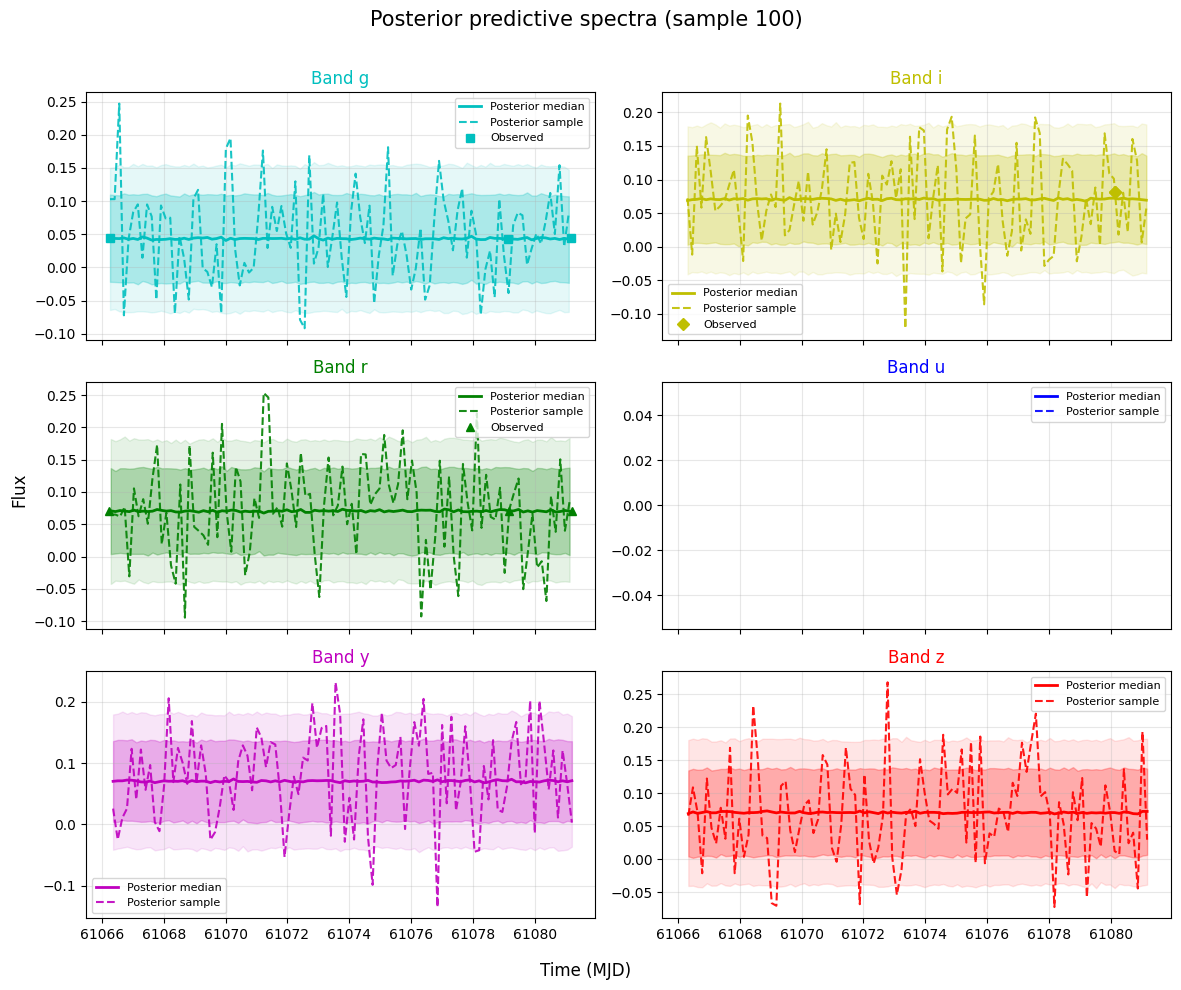

In [ ]:
band_colors = {
    "u": "#0000FF",
    "g": "#00BFBF",
    "r": "#008000",
    "i": "#BFBF00",
    "z": "#FF0000",
    "y": "#BF00BF",
}
band_markers = {
    "u": "o",
    "g": "s",
    "r": "^",
    "i": "D",
    "z": "v",
    "y": "x",
}

sample_idx = 100

# Observed data
obs_band_strs = np.array([idx_to_bandstr[b.item()] for b in bands])

# Posterior prediction grid
pred_band_strs = np.array([idx_to_bandstr[b.item()] for b in bands_fake])

unique_bands = np.unique(pred_band_strs)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

for ax, b in zip(axes, unique_bands):

    # -----------------------------
    # Posterior prediction grid
    # -----------------------------
    pred_mask = pred_band_strs == b

    samples_band = posterior_spectra[:, pred_mask]

    q05, q16, q50, q84, q95 = np.percentile(
        samples_band,
        [5, 16, 50, 84, 95],
        axis=0,
    )

    realization = samples_band[sample_idx]
    posterior_times = jnp.linspace(times[0], times[-1], 600)

    order_pred = np.argsort(posterior_times[pred_mask])

    t_pred = posterior_times[pred_mask][order_pred]

    q05 = q05[order_pred]
    q16 = q16[order_pred]
    q50 = q50[order_pred]
    q84 = q84[order_pred]
    q95 = q95[order_pred]
    realization = realization[order_pred]

    # -----------------------------
    # Observations
    # -----------------------------
    obs_mask = obs_band_strs == b

    order_obs = np.argsort(times[obs_mask])

    t_obs = times[obs_mask][order_obs]
    obs = lc_obs[obs_mask][order_obs]

    color = band_colors[b]
    marker = band_markers[b]

    # 90% CI
    ax.fill_between(
        t_pred,
        q05,
        q95,
        color=color,
        alpha=0.10,
    )

    # 68% CI
    ax.fill_between(
        t_pred,
        q16,
        q84,
        color=color,
        alpha=0.25,
    )

    # Posterior median
    ax.plot(
        t_pred,
        q50,
        color=color,
        lw=2,
        label="Posterior median",
    )

    # One posterior sample
    ax.plot(
        t_pred,
        realization,
        "--",
        color=color,
        lw=1.5,
        alpha=0.9,
        label="Posterior sample",
    )

    # Observed data
    # -----------------------------
    # Observations (if any)
    # -----------------------------
    obs_mask = obs_band_strs == b

    has_obs = np.any(obs_mask)

    if has_obs:
        order_obs = np.argsort(times[obs_mask])
        t_obs = times[obs_mask][order_obs]
        obs = lc_obs[obs_mask][order_obs]

        ax.plot(
            t_obs,
            obs,
            linestyle="none",
            marker=marker,
            color=color,
            markersize=6,
            label="Observed",
        )
    ax.set_title(f"Band {b}", color=color)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.supxlabel("Time (MJD)")
fig.supylabel("Flux")
fig.suptitle(f"Posterior predictive spectra (sample {sample_idx})", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
print(np.unique(obs_band_strs, return_counts=True))
print(np.unique(pred_band_strs, return_counts=True))

for b in ["u", "g", "r", "i", "z", "y"]:
    print(
        b,
        np.sum(obs_band_strs == b),
        np.sum(pred_band_strs == b),
    )

(array(['g', 'i', 'r'], dtype='<U1'), array([3, 2, 3]))
(array(['g', 'i', 'r', 'u', 'y', 'z'], dtype='<U1'), array([100, 100, 100, 100, 100, 100]))
u 0 100
g 3 100
r 3 100
i 2 100
z 0 100
y 0 100


u (5000, 100) finite: 0
g (5000, 100) finite: 500000
r (5000, 100) finite: 500000
i (5000, 100) finite: 500000
z (5000, 100) finite: 500000
y (5000, 100) finite: 500000


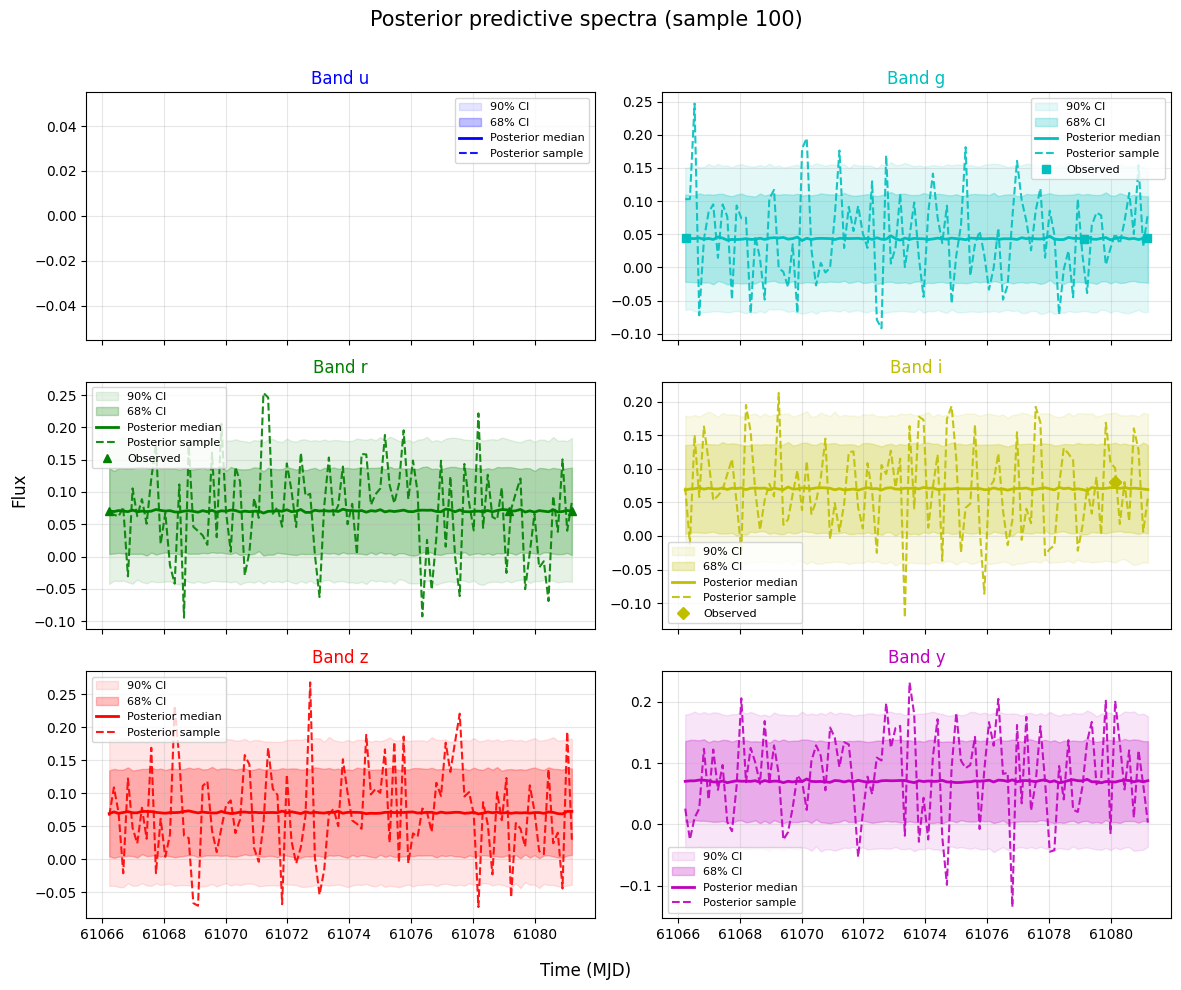

In [ ]:
band_colors = {
    "u": "#0000FF",
    "g": "#00BFBF",
    "r": "#008000",
    "i": "#BFBF00",
    "z": "#FF0000",
    "y": "#BF00BF",
}

band_markers = {
    "u": "o",
    "g": "s",
    "r": "^",
    "i": "D",
    "z": "v",
    "y": "x",
}

sample_idx = 100
obs_band_strs = np.array([idx_to_bandstr[b.item()] for b in bands])
pred_band_strs = np.array([idx_to_bandstr[b.item()] for b in bands_fake])
unique_bands = ["u", "g", "r", "i", "z", "y"]
n_pred_per_band = posterior_spectra.shape[1] // len(unique_bands)
posterior_times_one_band = np.linspace(times[0], times[-1], n_pred_per_band)

posterior_times_full = np.repeat(posterior_times_one_band, len(unique_bands))

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()
for i, b in enumerate(unique_bands):
    ax = axes[i]
    color = band_colors[b]
    marker = band_markers[b]
    # Posterior 
    pred_mask = pred_band_strs == b
    has_pred = np.any(pred_mask)
    if has_pred:
        samples_band = posterior_spectra[:, pred_mask]
        print(b, samples_band.shape, "finite:", np.isfinite(np.asarray(samples_band)).sum())
        q05, q16, q50, q84, q95 = np.percentile(samples_band, [5, 16, 50, 84, 95], axis=0)
        realization = samples_band[sample_idx]
        t_pred = posterior_times_full[pred_mask]
        order_pred = np.argsort(t_pred)
        t_pred = t_pred[order_pred]
        q05 = q05[order_pred]
        q16 = q16[order_pred]
        q50 = q50[order_pred]
        q84 = q84[order_pred]
        q95 = q95[order_pred]
        realization = realization[order_pred]

        # 90% posterior interval
        ax.fill_between(
            t_pred,
            q05,
            q95,
            color=color,
            alpha=0.10,
            label="90% CI",
        )

        # 68% posterior interval
        ax.fill_between(
            t_pred,
            q16,
            q84,
            color=color,
            alpha=0.25,
            label="68% CI",
        )

        # Posterior median
        ax.plot(t_pred, q50, color=color, lw=2, label="Posterior median")

        # One realization
        ax.plot(t_pred, realization, "--", color=color, lw=1.5, alpha=0.9, label="Posterior sample")

    # Observations
    obs_mask = obs_band_strs == b
    has_obs = np.any(obs_mask)
    if has_obs:
        t_obs = times[obs_mask]
        obs = lc_obs[obs_mask]
        order_obs = np.argsort(t_obs)
        t_obs = t_obs[order_obs]
        obs = obs[order_obs]
        ax.plot(
            t_obs,
            obs,
            linestyle="none",
            marker=marker,
            color=color,
            markersize=6,
            label="Observed",
        )

    # Axis limits
    vals = []

    if has_pred:
        vals.extend([
            np.asarray(q05).ravel(),
            np.asarray(q95).ravel(),
            np.asarray(realization).ravel(),
        ])

    if has_obs:
        vals.append(
            np.asarray(obs).ravel()
        )

    if len(vals) > 0:

        vals = np.concatenate(vals)
        vals = vals[np.isfinite(vals)]

        if len(vals) > 0:

            ymin = vals.min()
            ymax = vals.max()

            pad = 0.05 * max(ymax - ymin, 1e-10)

            ax.set_ylim(
                ymin - pad,
                ymax + pad,
            )
    ax.set_title(f"Band {b}", color=color)
    ax.grid()
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(
            handles,
            labels,
            fontsize=8,
            loc="best",
        )
fig.supxlabel("Time (MJD)")
fig.supylabel("Flux")
fig.suptitle(f"Posterior predictive spectra (sample {sample_idx})")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
print(np.shape(posterior_spectra))

(5000, 600)


[61066.22895891 61066.25034739 61079.14235439 61079.16580924
 61080.15123313 61080.15165097 61081.18165556 61081.2057113 ]
[61066.22895891 61066.38023924 61066.53151956 61066.68279989
 61066.83408022 61066.98536054 61067.13664087 61067.2879212
 61067.43920153 61067.59048185 61067.74176218 61067.89304251
 61068.04432284 61068.19560316 61068.34688349 61068.49816382
 61068.64944414 61068.80072447 61068.9520048  61069.10328513
 61069.25456545 61069.40584578 61069.55712611 61069.70840643
 61069.85968676 61070.01096709 61070.16224742 61070.31352774
 61070.46480807 61070.6160884  61070.76736873 61070.91864905
 61071.06992938 61071.22120971 61071.37249003 61071.52377036
 61071.67505069 61071.82633102 61071.97761134 61072.12889167
 61072.280172   61072.43145232 61072.58273265 61072.73401298
 61072.88529331 61073.03657363 61073.18785396 61073.33913429
 61073.49041462 61073.64169494 61073.79297527 61073.9442556
 61074.09553592 61074.24681625 61074.39809658 61074.54937691
 61074.70065723 61074.851

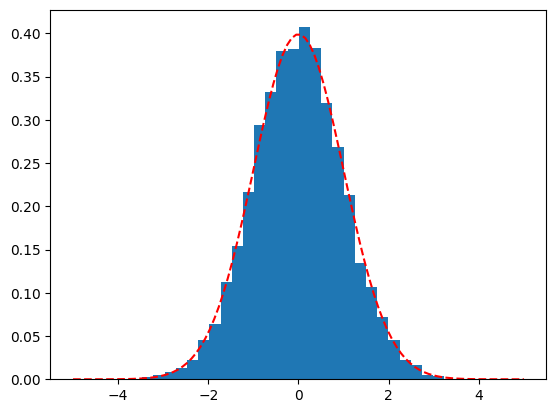

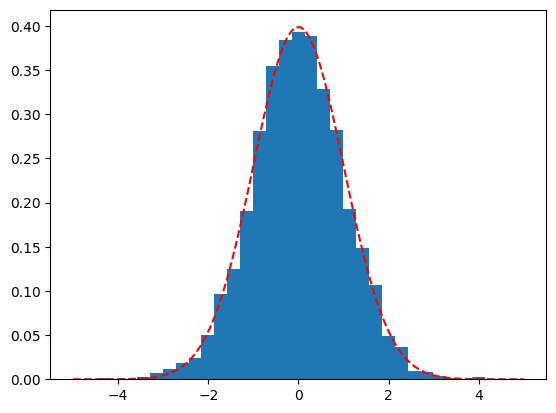

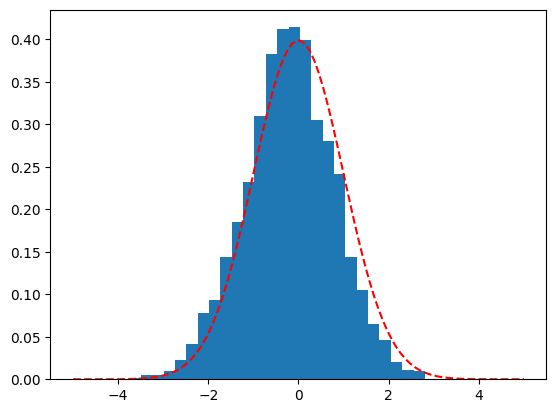

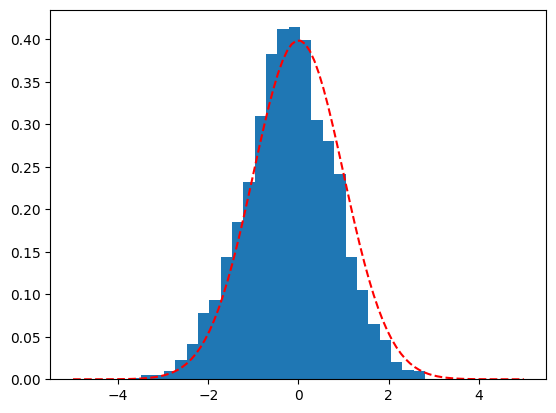

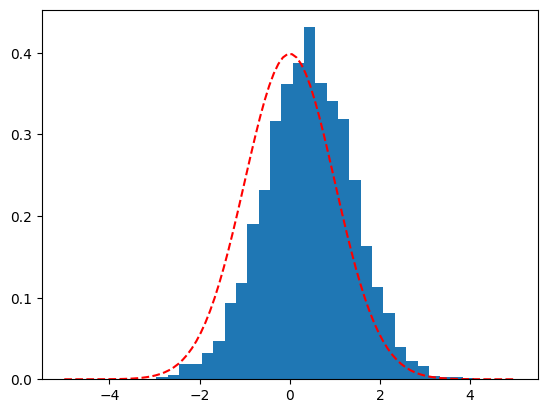

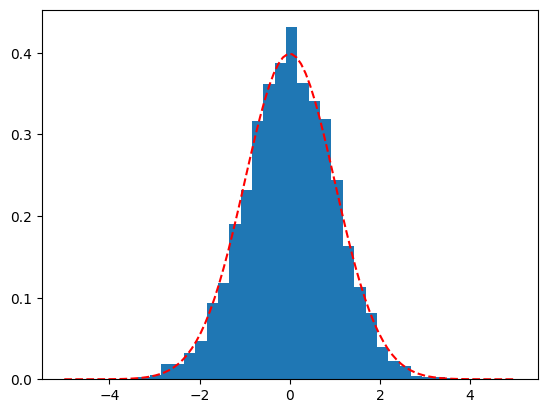

In [ ]:
print(times)
print(posterior_times_one_band)



for observation_id in range(len(lc_obs)):
    post_times_id = jnp.argmin(
        jnp.abs(posterior_times_one_band - times[observation_id]))

    residuals = (posterior_spectra[:, post_times_id] - lc_obs[observation_id]) / jnp.mean(sigma_samples)
    if jnp.all(jnp.isnan(residuals)):
        print("skipped")
        continue
    plt.hist(residuals[~jnp.isnan(residuals)], density=True, bins=30)
    plt.plot(jnp.linspace(-5, 5, 100), jax.scipy.stats.norm.pdf(jnp.linspace(-5, 5, 100)), 
             color="r", linestyle="--", label="Standard Normal")
    # plt.title(f"Band{idx_to_bandstr[bands[observation_id]]} Residuals Histogram")
    plt.show()


# With my written functions and caskade-friendly 

In [1]:
import cosmographi.source.agn_fitting as f
from cosmographi import source_factory
import caskade as ck
import jax
import matplotlib.pyplot as plt





#TODO: need x0

2026-08-17 12:13:43.066840: W external/xla/xla/service/platform_util.cc:220] unable to create StreamExecutor for CUDA:0: CUDA error: : CUDA_ERROR_UNKNOWN: unknown error


In [6]:
key = jax.random.key(42)
I = RubinObservatory()
fit = f.AGNFit(name="fit", key=key, instrument=I, y=[56], y_err=[1])
print(fit.all_params)
fit.graphviz()


TypeError: LogPosterior.__init__() missing 7 required positional arguments: 'start_time', 'end_time', 'obs_t', 'band', 'exp_time', 'sky_brightness', and 'PSF_Aeff'

In [5]:
np.random.seed(0)
key, key2 = jax.random.split(jax.random.PRNGKey(0))

# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 50000;
        """
    survey_df = pd.read_sql_query(query, conn)
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values


# Create source
#####################################################################
perturbations = generate_perturbations_vector (alpha=0.7, n_samples = 4000)
print(perturbations)
C = cp.Cosmology()
source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, A_V_c00mw=0.1, R_V_c00mw=3.1, blackhole_mass=1e10*M_sun, accretion_rate=M_sun, rin_to_rng=6, inclination_angle=0, perturbations=perturbations, start_time=60900, end_time=65000)



#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band, return_dict=True)
nfilter = len(I.throughput.bands)
print(I.get_values().shape)

# Generate mock SN
#####################################################################
Nsn = 1
t_range = (np.min(survey_t), np.max(survey_t))
source_t = np.random.uniform(*t_range, Nsn)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing


source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)

print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin = np.full(Nsn, np.min(survey_t)),
    source_tmax= np.full(Nsn, np.max(survey_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
# TODO: MAKE PRIORS
# P = cp.source.prior.SALT2_SK16Prior()
# x1, c = P.prior_sample(source_t.shape[0])
# S.x1 = x1
# S.c = c
sel_src = np.sort(list(source_matches.keys()))
print(sel_src)

# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)
keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))


# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time.time()
LCs = []
nobs = len(keys)

#TODO: had to lower, what is eating up my memory??

batch_size = 50

print("batch_size =", batch_size)
i = 0
print("keys", keys[i:i+batch_size].shape)
print("bands", bands[i:i+batch_size].shape)
print("exp_times", exp_times[i:i+batch_size].shape)
print("sky_brightnesses", sky_brightnesses[i:i+batch_size].shape)
print("PSF_Aeffs", PSF_Aeffs[i:i+batch_size].shape)
print("obs_t", obs_t[i:i+batch_size].shape)
print("source_params", source_params[i:i+batch_size].shape)
print("survey_params", survey_params[i:i+batch_size].shape)

for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],  
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)

seli = sel_src[0]
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
times = obs_t[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]
lc_err = LCs[0][spot : spot + len(source_matches[seli])]

print(lc_obs)



[-1.88088626 -3.17437367 -1.15428244 ...  2.19879719  0.41111614
  0.31940836]
(1,)
[0.83781118]
Matching sources to survey...
Matched 1 sources to survey observations.
Matched 1 sources worth examining.
[0]
batch_size = 50
keys (8, 2)
bands (8,)
exp_times (8,)
sky_brightnesses (8,)
PSF_Aeffs (8,)
obs_t (8,)
source_params (8, 2)
survey_params (8, 1)
[[0.0026126 ]
 [0.00166664]
 [0.00158898]
 [0.00259391]
 [0.0030336 ]
 [0.00295978]
 [0.00164159]
 [0.0025937 ]]


In [ ]:
times = jnp.linspace(start=S.start_time.value, stop=S.end_time.value, num=len(S.perturbations.value))
start_idx = jnp.searchsorted(times, cp.utils.flux.observer_to_rest_time(obs_t[0, z)) - 1
end_idx = jnp.searchsorted(times, cp.utils.flux.observer_to_rest_time(obs_t[-1])) + 1


TypeError: observer_to_rest_time() missing 1 required positional argument: 'z'

In [ ]:
kwargs = {"obs_t": obs_t, "band": bands, "exp_time": exp_times, "sky_brightness": sky_brightnesses, "PSF_Aeff": PSF_Aeffs, "times": times, "z": source_z, 
        "blackhole_mass": S.blackhole_mass.value,
        "accretion_rate": S.accretion_rate.value,
        "rin_to_rng": S.rin_to_rng.value,
        "inclination_angle": S.inclination_angle.value,
        "luminosity_density_scaling": S.luminosity_density_scaling.value,
        "A_V_c00mw": S.A_V_c00mw.value,
        "R_V_c00mw": S.R_V_c00mw.value,
        "alpha": 1.0,
        "A": 1.0,
        "perturbations": S.perturbations.value[start_idx:end_idx],
        "start_time": times[start_idx],
        "end_time": times[end_idx]
}



In [ ]:
keys = jax.random.split(jax.random.key(42))
#TODO: check key management

# kwargs = {"band": bands, "exp_time": exp_times, "sky_brightness": sky_brightnesses, "PSF_Aeff": PSF_Aeffs, "times": times, "z": source_z}
fitter = f.AGNFit(name="fit", key=keys[0], instrument=I, y=lc_obs, y_err=lc_err, **kwargs)

# fitter.log_posterior.log_likelihood.source.blackhole_mass.to_dynamic()
# fitter.log_posterior.log_likelihood.source.accretion_rate.to_dynamic()
# fitter.log_posterior.log_likelihood.source.rin_to_rng.to_dynamic()
# fitter.log_posterior.log_likelihood.source.inclination_angle.to_dynamic()
# fitter.log_posterior.log_likelihood.source.A_V_c00mw.to_dynamic()
# fitter.log_posterior.log_likelihood.source.R_V_c00mw.to_dynamic()
fitter.log_posterior.log_likelihood.source.perturbations.to_dynamic()
fitter.log_posterior.log_likelihood.source.t0.to_static()
fitter.log_posterior.log_likelihood.instrument.throughput.air_mass.to_static()
fitter.log_posterior.log_prior.alpha.to_dynamic()
fitter.log_posterior.log_prior.A.to_dynamic()

print(fitter.dynamic_params)

(alpha, A, perturbations)


{'blackhole_mass': Array(1.98847e+40, dtype=float64), 'accretion_rate': Array(1.98847e+30, dtype=float64), 'inclination_angle': Array(0, dtype=int64, weak_type=True), 'rin_to_rng': Array(6, dtype=int64, weak_type=True), 'alpha': 0.7, 'A': 1, 'perturbations': Array([ 0.50490865, -0.35891069, -1.64598452, -4.96394684, -3.89815707,
        0.98403131, -1.86536041, -0.17219778,  0.76900903,  3.99488627,
        2.80812819,  2.27438461,  1.88426062,  3.12819646,  1.66531484,
        6.04526794], dtype=float64)}
caling warmup.run
calling warmup complete


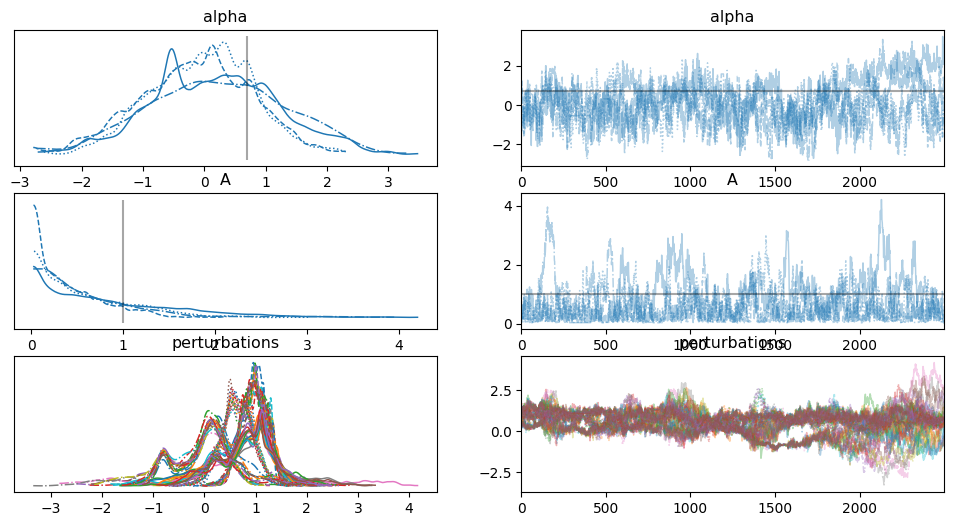

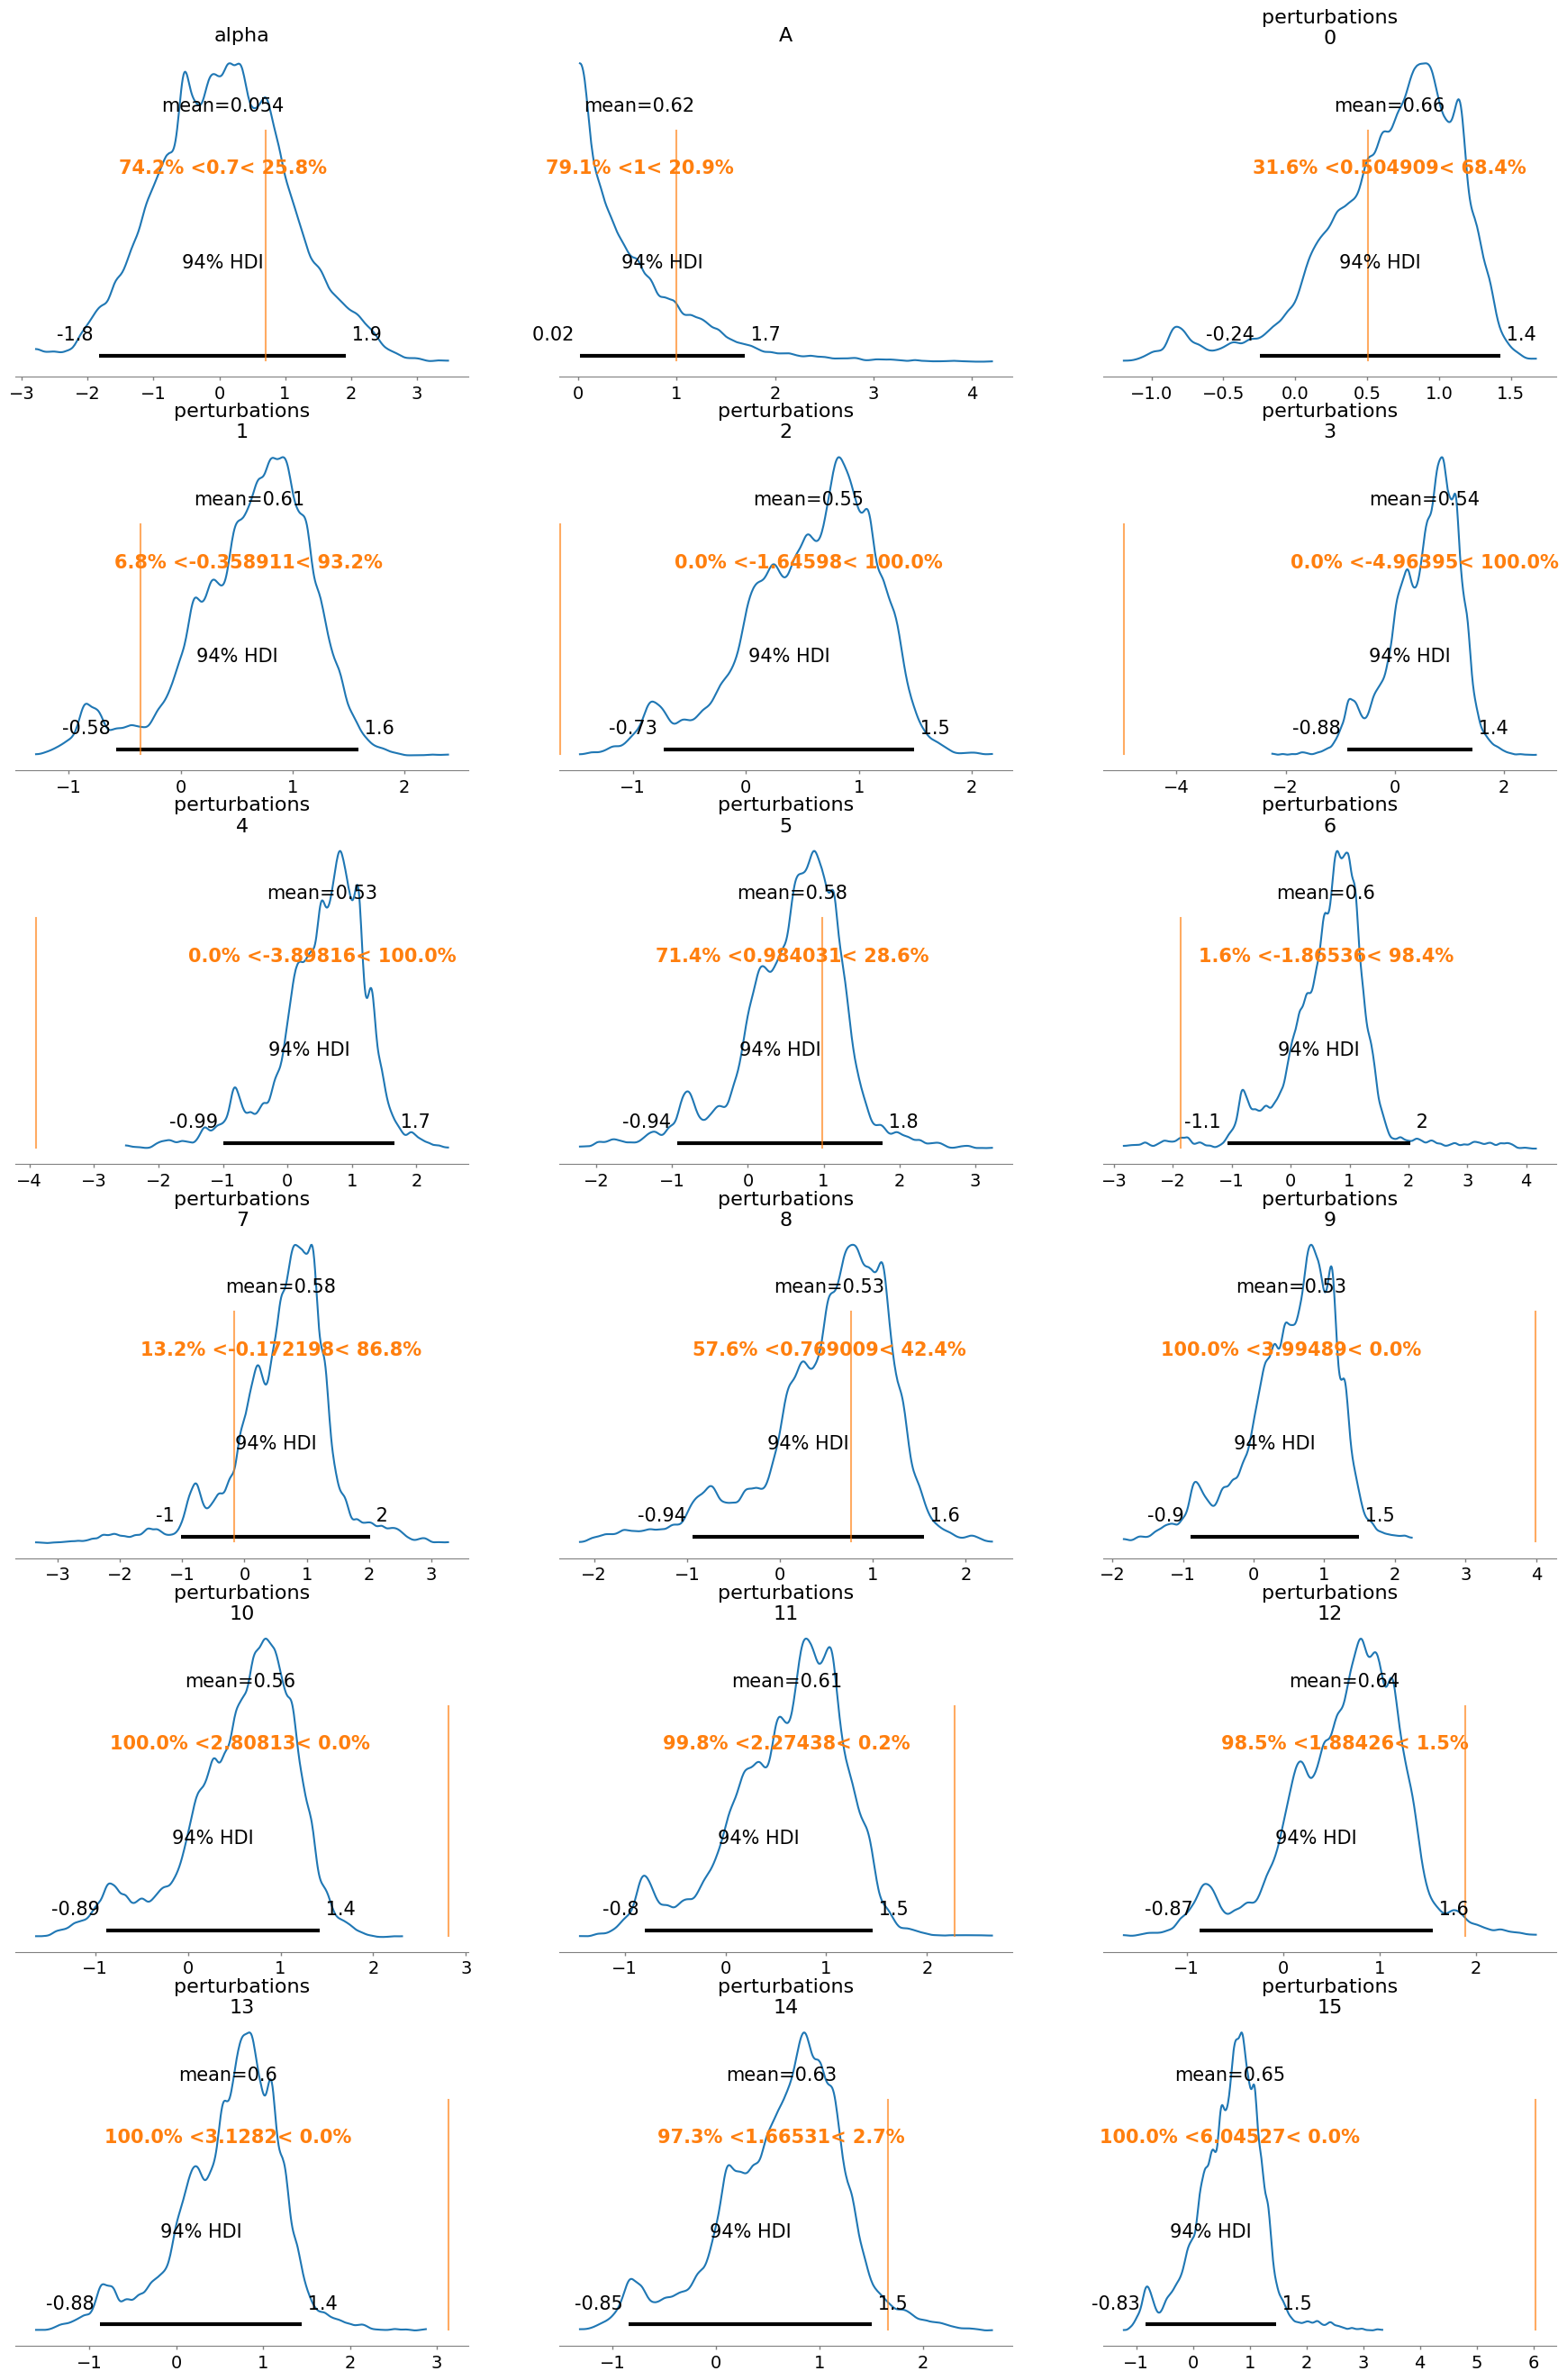

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:233: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


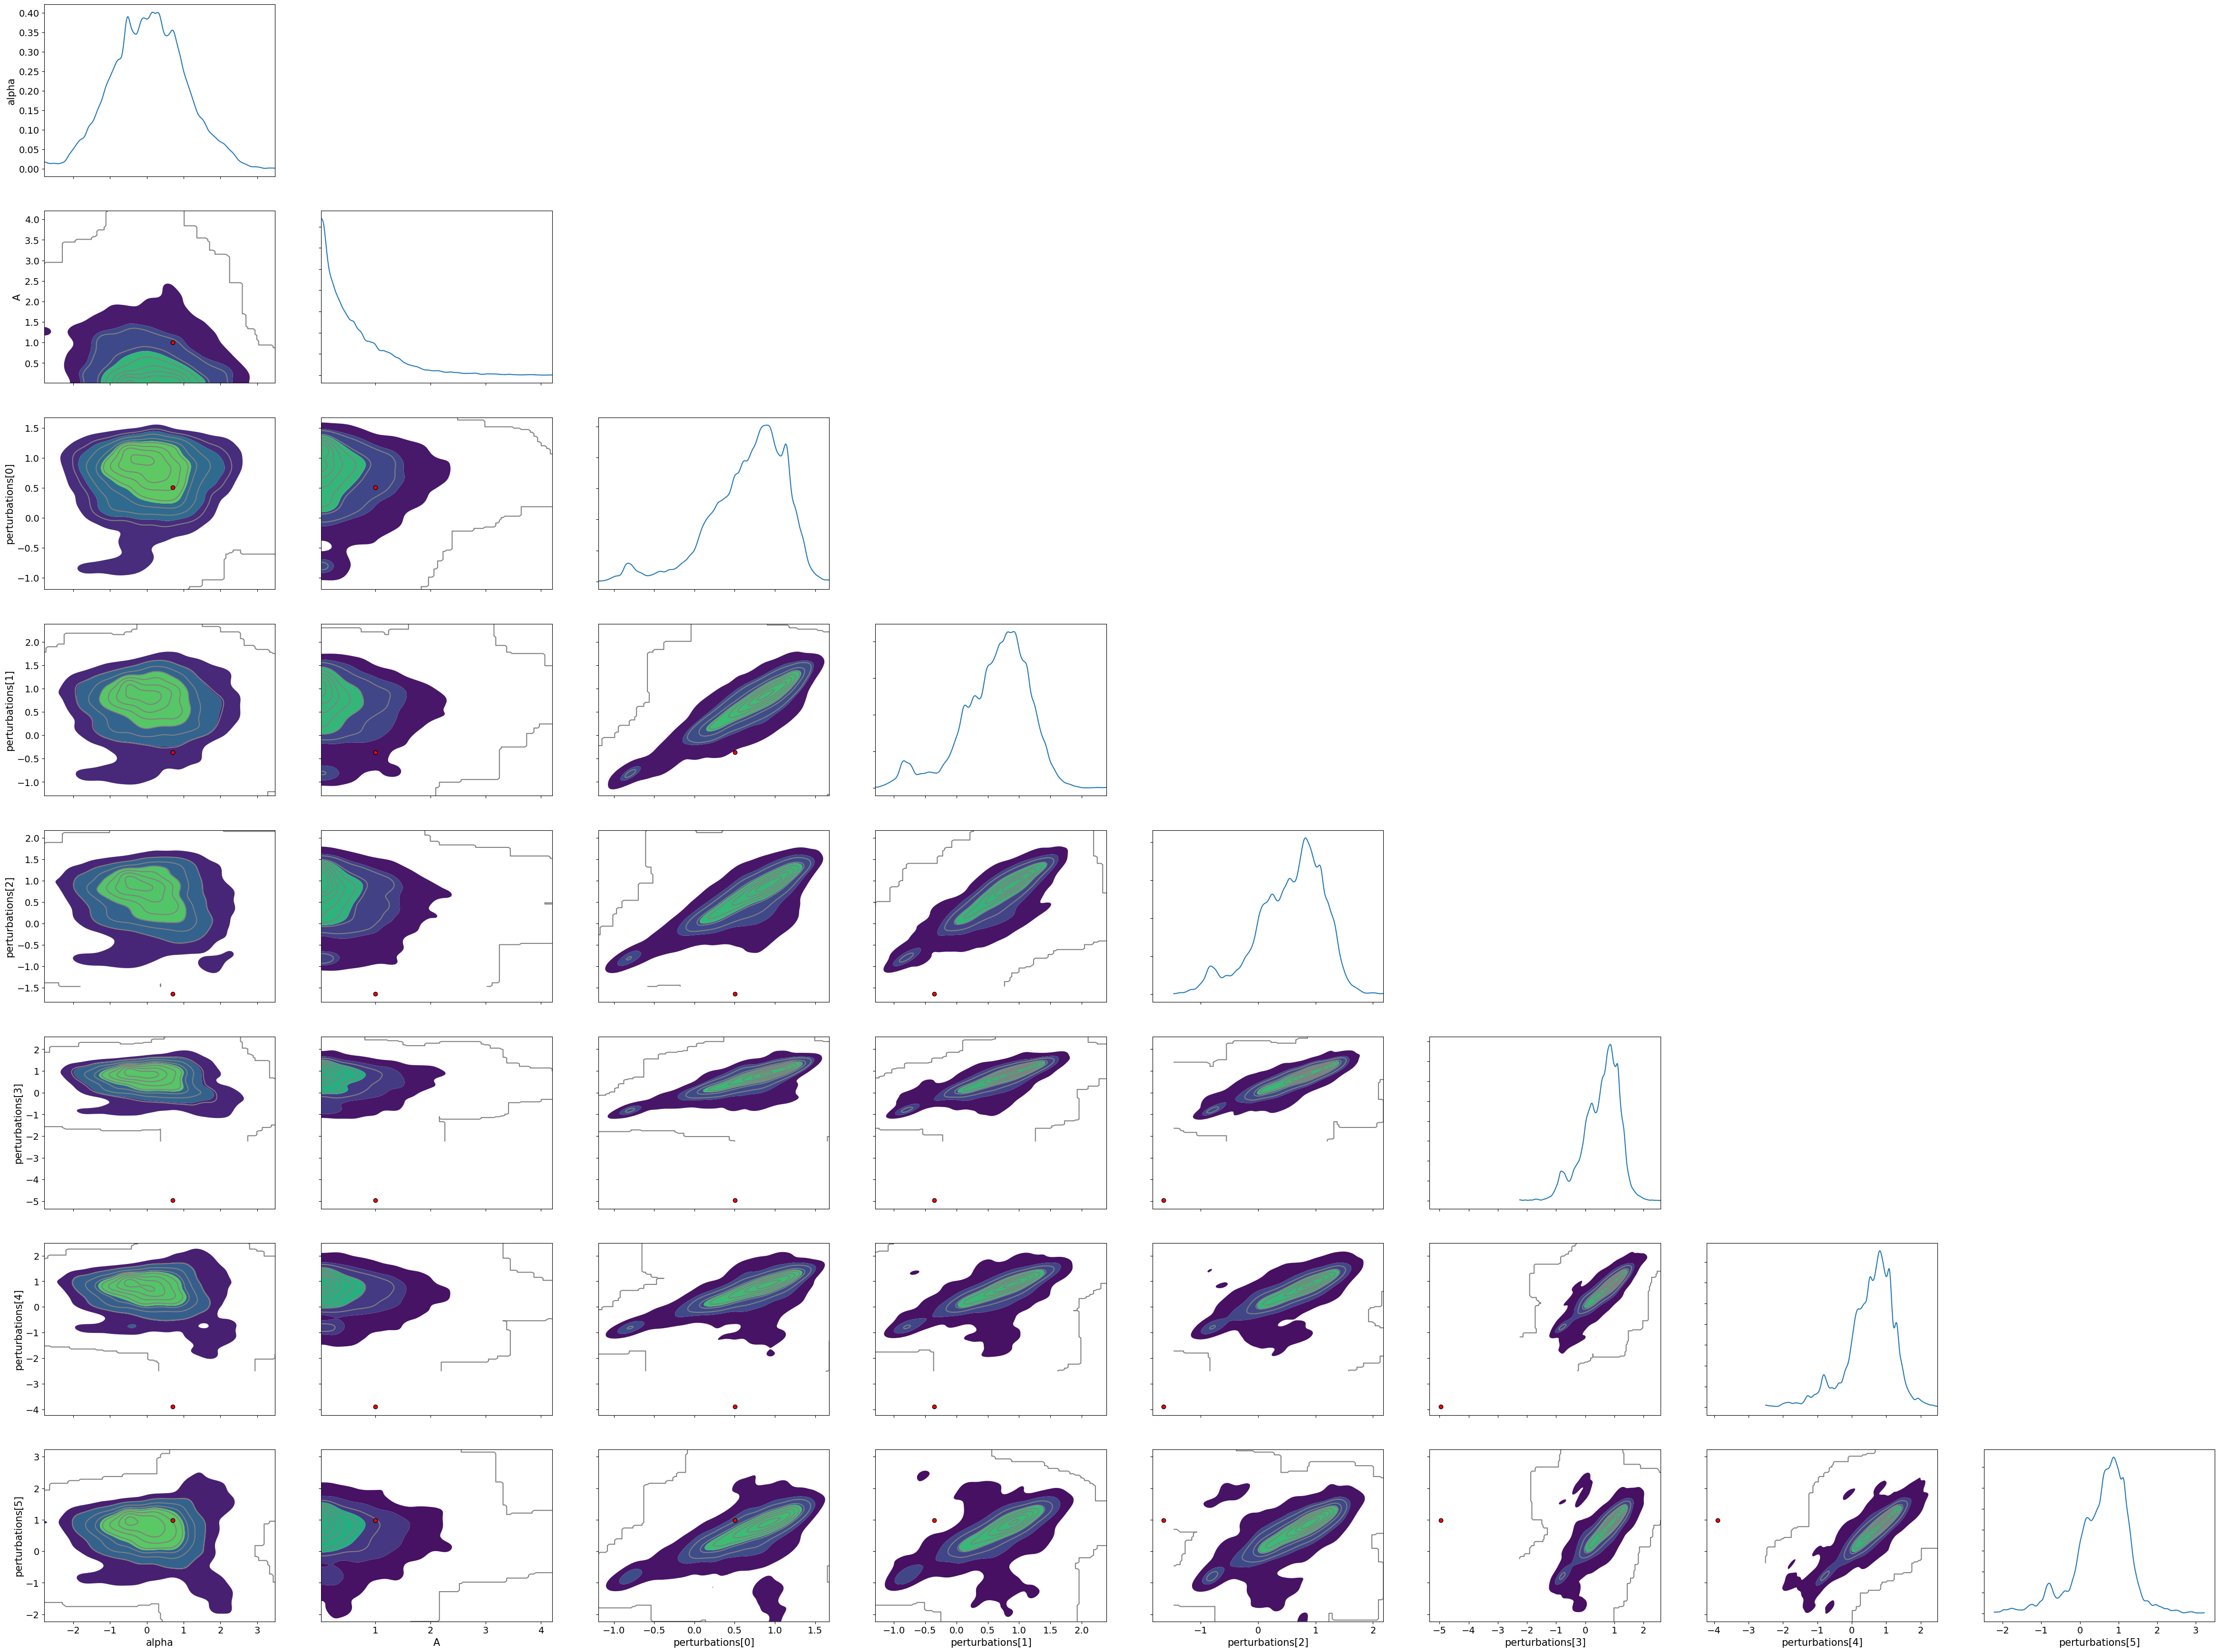

In [ ]:
true_values = {"blackhole_mass": S.blackhole_mass.value, "accretion_rate": S.accretion_rate.value, "inclination_angle": S.inclination_angle.value, "rin_to_rng": S.rin_to_rng.value, "alpha": 0.7, "A": 1, "perturbations":S.perturbations.value[start_idx:end_idx]}
print(true_values)
d = fitter.plot(true_values=true_values)


In [ ]:
print(obs_t)


true_perts = []
for time in obs_t:
    true_perts.append(S.perturbations.value[jnp.searchsorted(times, time)])


[61066.22895891 61066.25034739 61079.14235439 61079.16580924
 61080.15123313 61080.15165097 61081.18165556 61081.2057113 ]
61002.52563140785


In [ ]:
print(times[start_idx], times[end_idx])
print(obs_t[0], obs_t[-1])

61066.09152288072 61082.495623905976
61066.22895890815 61081.20571130473


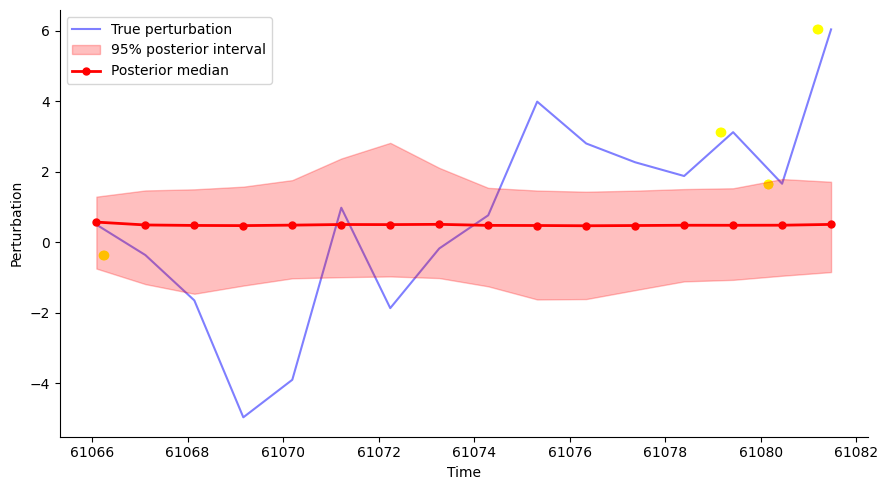

In [ ]:
idata = az.from_dict(d)
posterior = idata.posterior["perturbations"]

posterior_median = posterior.median(dim=("chain", "draw")).values

posterior_lower = posterior.quantile(0.025, dim=("chain", "draw")).values

posterior_upper = posterior.quantile(0.975, dim=("chain", "draw")).values


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    times[start_idx:end_idx],
    S.perturbations.value[start_idx:end_idx],
    color="blue",
    linewidth=1.5,
    label="True perturbation",
    alpha=0.5,
    zorder=1
)

ax.scatter(
    obs_t,
    true_perts,
    color="yellow"
    
)


ax.fill_between(
    times[start_idx:end_idx],
    posterior_lower,
    posterior_upper,
    color="red",
    alpha=0.25,
    label="95% posterior interval",
    zorder=2
)


ax.plot(
    times[start_idx:end_idx],
    posterior_median,
    color="red",
    marker="o",
    markersize=5,
    linewidth=2,
    label="Posterior median",
    zorder=3
)

ax.set_xlabel("Time")
ax.set_ylabel("Perturbation")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

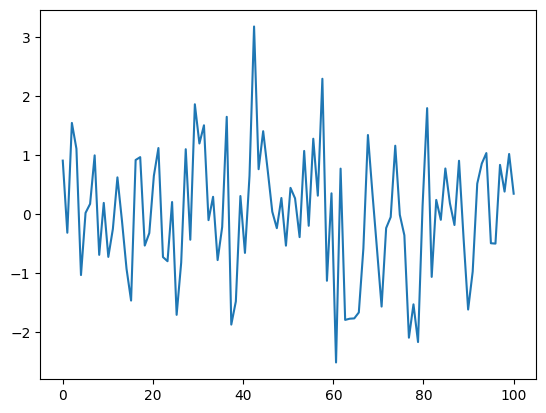

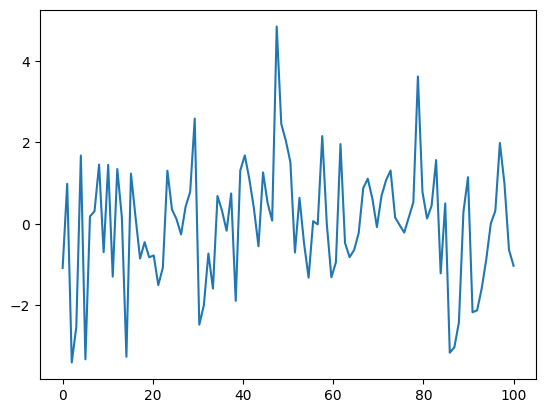

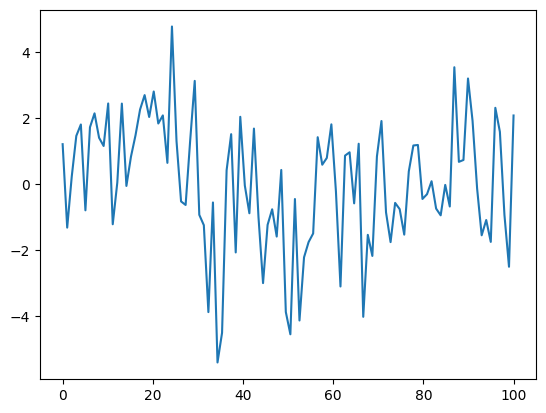

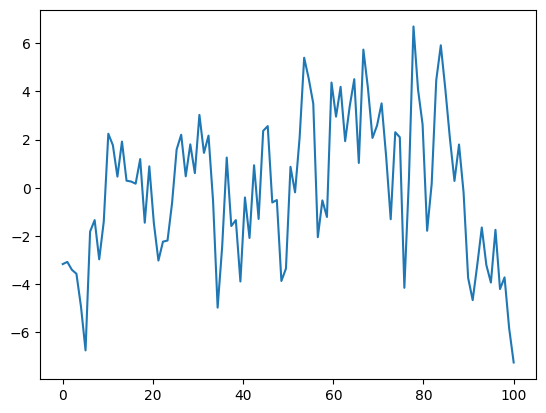

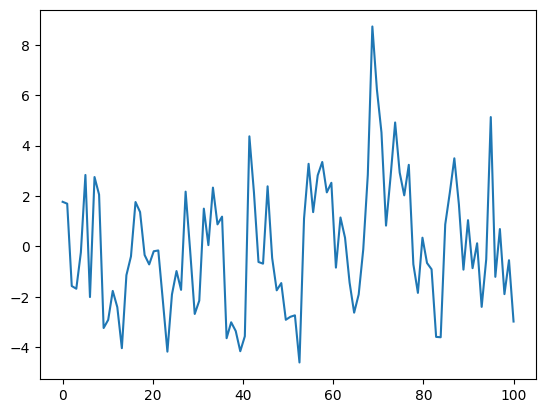

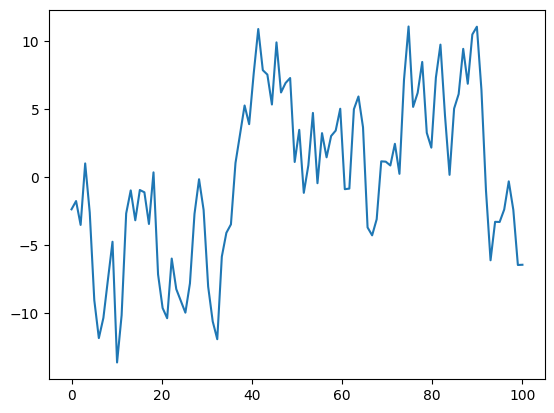

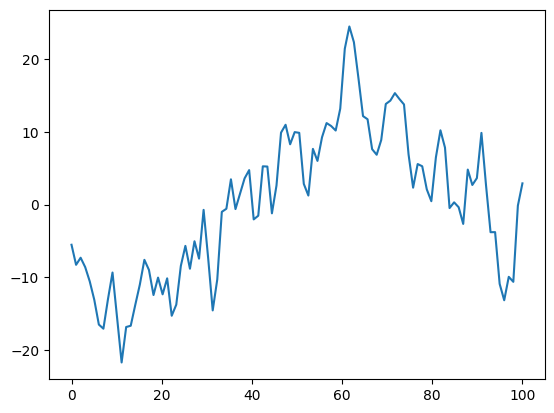

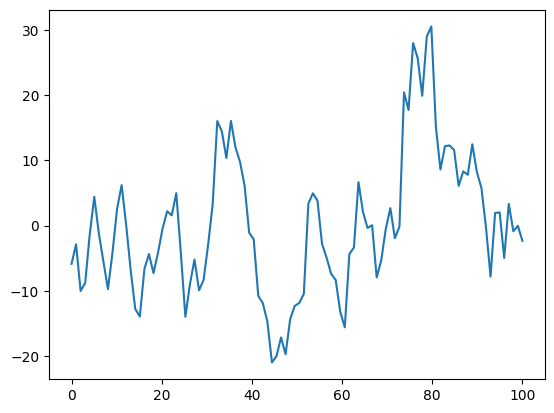

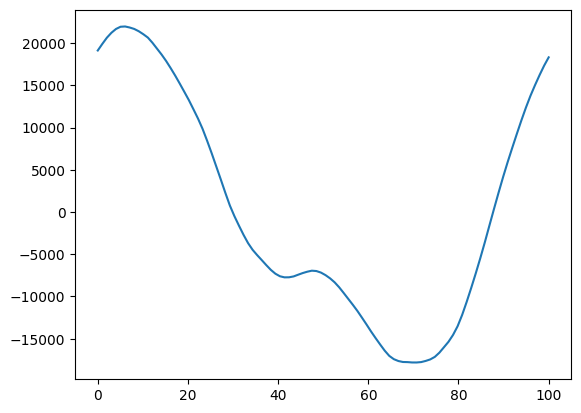

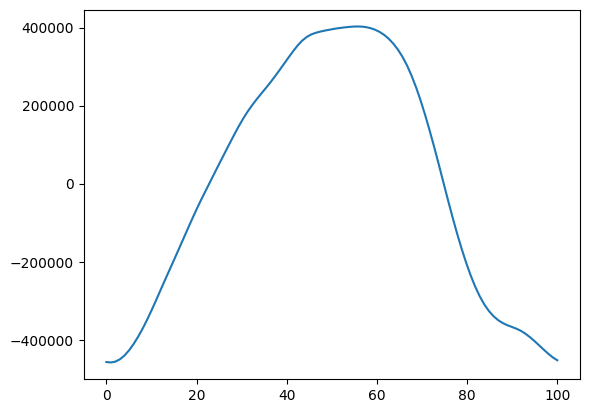

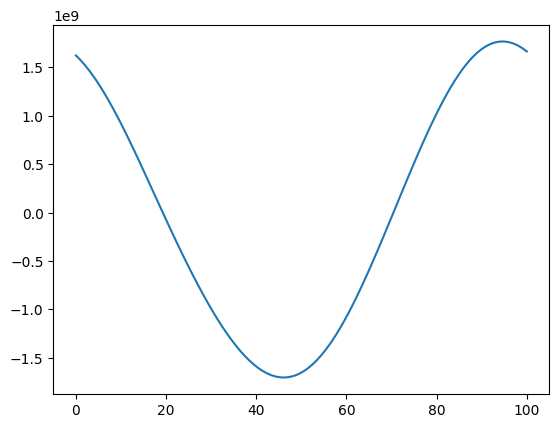

In [ ]:
alphas = [0.1, 0.5, 0.7, 1, 1.1, 1.5, 1.7, 2, 5, 7, 10]

for alpha in alphas:
    samples = generate_perturbations_vector(alpha, 100)
    times = jnp.linspace(start=0, stop=100, num=100)
    plt.plot(times, samples)
    plt.show()